In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.functional as F
import cv2
import os
import random

from torchvision.transforms import v2
from utils import is_char_correct_with_allowance, show_img, split_into_char_images

In [2]:
train_data_dir = "./transformer_train_data"
seed = 42

torch.manual_seed(seed)
np.random.seed(seed)

In [3]:
char_classes = {
    "0": 0,
    "1": 1,
    "2": 2,
    "3": 3,
    "4": 4,
    "5": 5,
    "6": 6,
    "7": 7,
    "8": 8,
    "9": 9,
    "a": 10,
    "b": 11,
    "c": 12,
    "d": 13,
    "e": 14,
    "f": 15,
    "g": 16,
    "h": 17,
    "i": 18,
    "j": 19,
    "k": 20,
    "l": 21,
    "m": 22,
    "n": 23,
    "o": 24,
    "p": 25,
    "q": 26,
    "r": 27,
    "s": 28,
    "t": 29,
    "u": 30,
    "v": 31,
    "w": 32,
    "x": 33,
    "y": 34,
    "z": 35,
}
num_classes = len(char_classes)
print(num_classes)

36


# Setup Datasets

In [4]:
def collate_fn(batch):
    """
    batch: list of (fname, imgs_tensor, label_tensor)
    imgs_tensor -> [N_i, C, H, W]
    label_tensor -> [N_i] or [N_i, num_classes]
    """
    fnames, seqs, labels = zip(*batch)

    # Compute max sequence length in the batch
    max_len = max(seq.size(0) for seq in seqs)

    padded_imgs = []
    padded_labels = []
    mask = []

    for imgs, lbls in zip(seqs, labels):
        pad_len = max_len - imgs.size(0)

        # Pad image sequence
        pad_img = torch.zeros((pad_len, *imgs.shape[1:]), dtype=imgs.dtype)
        padded_seq = torch.cat([imgs, pad_img], dim=0)
        padded_imgs.append(padded_seq)

        # Pad labels (support scalar or one-hot)
        pad_lbl = torch.zeros((pad_len, *lbls.shape[1:]), dtype=lbls.dtype)
        padded_lbl = torch.cat([lbls, pad_lbl], dim=0)
        padded_labels.append(padded_lbl)

        # Create mask: 1 for valid tokens, 0 for padded ones
        mask.append(torch.cat([torch.ones(imgs.size(0)), torch.zeros(pad_len)]))

    padded_imgs = torch.stack(padded_imgs)       # [B, max_N, C, H, W]
    padded_labels = torch.stack(padded_labels)   # [B, max_N, ...]
    mask = torch.stack(mask).bool()              # [B, max_N]

    return fnames, padded_imgs, padded_labels, mask

In [5]:
import os, random, cv2, torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

validation_set_fraction = 0.1
seed = 42  # for reproducibility


class CharSequenceDataset(Dataset):
    """
    Loads sequences of characters from pre-split character images.
    File format: <captcha_label>_<char_index>_<index_in_captcha>.png
    """
    def __init__(self, data_dir="", is_train=True):
        self.data_dir = data_dir
        self.is_train = is_train

        all_files = [f for f in os.listdir(data_dir) if f.lower().endswith('.png')]
        if len(all_files) == 0:
            raise FileNotFoundError(f"No .png files found in {data_dir}")

        # Group files by captcha label
        sequences = {}
        for f in all_files:
            label_part = f.split('_')[0]
            sequences.setdefault(label_part, []).append(f)
        for k in sequences:
            sequences[k] = sorted(sequences[k], key=lambda x: int(x.split('_')[1]))
        self.sequences = list(sequences.items())

        # Train/val split
        random.seed(seed)
        random.shuffle(self.sequences)
        split_idx = int(len(self.sequences) * (1 - validation_set_fraction))
        if self.is_train:
            self.sequences = self.sequences[:split_idx]
        else:
            self.sequences = self.sequences[split_idx:]

        # Transform for validation (deterministic)
        self.val_transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.ToTensor(),
        ])

    def __len__(self):
        return len(self.sequences)

    def _random_affine_params(self):
        """Generate random shear parameters shared across CAPTCHA."""
        shear_x = random.uniform(-15, 15)
        shear_y = random.uniform(-5, 5)  # new Y shear
        scale = random.uniform(0.9, 1.1) 
        return shear_x, shear_y, scale
    
    def _apply_affine_to_all(self, imgs, shear_x, shear_y, scale):
        transformed_imgs = []
        for img in imgs:
            img = F.to_pil_image(img)
            """per-character random rotation"""
            angle = random.uniform(-30, 30)
            
            img = F.affine(
                img, 
                angle=angle, 
                translate=(0, 0), 
                scale=scale, 
                shear=[shear_x, shear_y])
            img = F.to_tensor(img)
            transformed_imgs.append(img)
        return transformed_imgs

    def __getitem__(self, index):
        label_str, char_files = self.sequences[index]
        label_idxes = [char_classes[c] for c in label_str]

        imgs = []
        for f in char_files:
            img_path = os.path.join(self.data_dir, f)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                raise FileNotFoundError(f"Cannot read image {img_path}")
            if img.shape[:2] != (42, 42):
                img = cv2.resize(img, (42, 42), interpolation=cv2.INTER_LINEAR)
            imgs.append(img)

        # Apply transforms
        if self.is_train:
            shear_x, shear_y, scale = self._random_affine_params()
            imgs = self._apply_affine_to_all(imgs, shear_x, shear_y, scale)
        else:
            imgs = [self.val_transform(img) for img in imgs]

        imgs_tensor = torch.stack(imgs)  # [N, C, H, W]
        label_tensor = torch.tensor(label_idxes)

        assert imgs_tensor.shape[0] == label_tensor.shape[0], \
            f"Mismatch between chars and labels in {label_str}"

        return label_str, imgs_tensor, label_tensor


# --- Create datasets ---
train_dataset = CharSequenceDataset(data_dir=train_data_dir, is_train=True)
val_dataset = CharSequenceDataset(data_dir=train_data_dir, is_train=False)

train_dataloader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=0, pin_memory=True, collate_fn=collate_fn)
val_dataloader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=0, pin_memory=True, collate_fn=collate_fn)

### Visualize the Data

torch.Size([7, 1, 42, 42])
torch.Size([7])


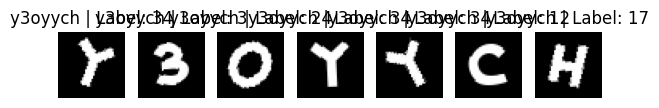

In [6]:
img_id, X_transformed, y = train_dataset[0]
print(X_transformed.shape)
print(y.shape)

plt.figure(figsize=(7, 4))
for i, img in enumerate(X_transformed):
    plt.subplot(1, len(X_transformed), i + 1)
    plt.imshow(img.squeeze(0).cpu().numpy(), cmap='gray')
    plt.axis('off')
    plt.title(f'{img_id} | Label: {y[i]}')
plt.show()

### Setup Cuda

In [7]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


# Import Model

In [8]:
from model import ImageSequenceClassifier


net = ImageSequenceClassifier()
net.to(device)

def count_params(net, trainable=False):
    if trainable:
        count = sum(p.numel() for p in net.parameters() if p.requires_grad)
    else:
        count = sum(p.numel() for p in net.parameters())
    return count

print(F'Network has {count_params(net, trainable=False)} parameters in total')
print(F'Network has {count_params(net, trainable=True)} trainable parameters in total')

Network has 787476 parameters in total
Network has 787476 trainable parameters in total


# Training

In [9]:
class EarlyStopping:
    def __init__(self, patience=5, delta=0):
        """
        Stops training if val_loss doesn't improve after `patience` epochs.
        delta: minimum change to qualify as an improvement
        verbose: whether to print messages
        """
        self.patience = patience
        self.delta = delta
        self.best_loss = None
        self.epochs_without_improvement = 0
        self.stop_training = False
        self.best_model_state = None
    
    def check_early_stopping(self, val_loss, model):
        """
        Call this at the end of each epoch.
        model: the network whose weights we want to save
        """
        if self.best_loss is None or val_loss < (self.best_loss - self.delta):
            self.best_loss = val_loss
            self.epochs_without_improvement = 0
            # Save a copy of the model weights
            self.best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print(f"Validation loss improved to {val_loss:.4f}. Saving model weights.")
        else:
            self.epochs_without_improvement += 1
            if self.epochs_without_improvement >= self.patience:
                self.stop_training = True
                print("Stopping early as no validation loss improvement has been observed.")
    
    def load_best_weights(self, model, device='cpu'):
        """
        Restore the model to the best validation loss weights
        """
        if self.best_model_state is not None:
            model.load_state_dict({k: v.to(device) for k, v in self.best_model_state.items()})
            print("Model weights restored to best validation loss.")

# Initialize early stopping class
early_stopping = EarlyStopping(patience=15, delta=0)

Epoch 1/300: 100%|█████████████████████████████████████████████████████████████████████| 53/53 [00:15<00:00,  3.38it/s]


Epoch [1/300] - Train Loss: 3.3170 - Val Loss: 2.5022 - Val Acc: 39.25%
Validation loss improved to 2.5022. Saving model weights.


Epoch 2/300: 100%|█████████████████████████████████████████████████████████████████████| 53/53 [00:14<00:00,  3.61it/s]


Epoch [2/300] - Train Loss: 1.9339 - Val Loss: 1.2103 - Val Acc: 76.38%
Validation loss improved to 1.2103. Saving model weights.


Epoch 3/300: 100%|█████████████████████████████████████████████████████████████████████| 53/53 [00:15<00:00,  3.42it/s]


...

Epoch [91/300] - Train Loss: 0.4486 - Val Loss: 0.4871 - Val Acc: 96.10%


Epoch 92/300: 100%|████████████████████████████████████████████████████████████████████| 53/53 [00:14<00:00,  3.74it/s]


Epoch [92/300] - Train Loss: 0.4474 - Val Loss: 0.4869 - Val Acc: 96.17%


Epoch 93/300: 100%|████████████████████████████████████████████████████████████████████| 53/53 [00:14<00:00,  3.76it/s]


Epoch [93/300] - Train Loss: 0.4464 - Val Loss: 0.4871 - Val Acc: 95.99%
Stopping early as no validation loss improvement has been observed.
Early stopping at epoch 93
Model weights restored to best validation loss.


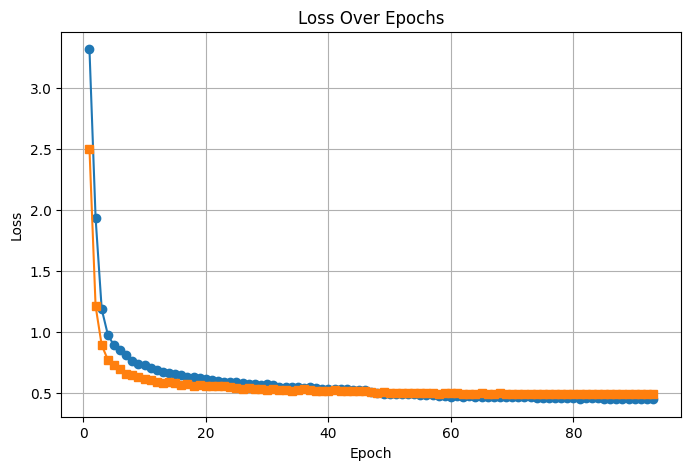

In [10]:
from tqdm import tqdm # for a progress bar

criterion = nn.CrossEntropyLoss(label_smoothing=0.05, reduction='none')
optimizer = torch.optim.Adam(net.parameters(), weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5,
)
num_epochs = 300

epoch_train_losses = []  # store loss for each epoch
epoch_val_losses = []

def compute_accuracy(logits, labels, mask):
    preds = logits.argmax(dim=-1)
    correct = ((preds == labels) * mask).sum().item()
    total = mask.sum().item()
    return correct, total

for epoch in range(num_epochs):
    net.train()  # set model to training mode
    running_loss = 0.0 
    # Running loss sums the loss values for each mini-batch, to later compute the average loss per epoch

    # Training
    for img_id, X_transformed, y, mask in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        X_transformed, y = X_transformed.to(device, non_blocking=True), y.to(device, non_blocking=True)
        mask = mask.to(device, non_blocking=True)

        # Forward pass
        y_pred_logits = net(X_transformed, mask)

        # Calculate loss
        B, N, num_classes = y_pred_logits.shape
        logits_flat = y_pred_logits.view(B*N, num_classes)  # [B*N, C]
        y_flat = y.view(B*N)                                # [B*N]
        mask_flat = mask.view(B*N)                          # [B*N]
        
        # Compute per-token loss
        loss_per_token = criterion(logits_flat, y_flat)     # [B*N]
        # Mask out padded tokens
        loss = (loss_per_token * mask_flat).sum() / mask_flat.sum()

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Validation
    val_loss = 0.0
    net.eval()

    correct_total = 0
    mask_total = 0
    
    with torch.no_grad():
        for img_id, X_transformed, y, mask in val_dataloader:
            X_transformed, y = X_transformed.to(device, non_blocking=True), y.to(device, non_blocking=True)
            mask = mask.to(device, non_blocking=True)
            
             # Forward pass
            y_pred_logits = net(X_transformed, mask)  
            B, N, num_classes = y_pred_logits.shape
            logits_flat = y_pred_logits.view(B*N, num_classes)  # [B*N, C]
            y_flat = y.view(B*N)                                # [B*N]
            mask_flat = mask.view(B*N)                          # [B*N]
            
            # Compute per-token loss
            loss_per_token = criterion(logits_flat, y_flat)     # [B*N]
            # Mask out padded tokens
            loss = (loss_per_token * mask_flat).sum() / mask_flat.sum()
            
            val_loss += loss.item()

            # ✅ accumulate accuracy over all batches
            correct, total = compute_accuracy(y_pred_logits, y, mask)
            correct_total += correct
            mask_total += total

    avg_train_loss = running_loss / len(train_dataloader)
    avg_val_loss = val_loss / len(val_dataloader)
    avg_val_acc = correct_total / mask_total
    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f} - Val Acc: {avg_val_acc*100:.2f}%")

    epoch_train_losses.append(avg_train_loss)
    epoch_val_losses.append(avg_val_loss)

    # Step the scheduler using validation loss
    scheduler.step(avg_val_loss)

    # Early stopping?
    early_stopping.check_early_stopping(avg_val_loss, net)
    if early_stopping.stop_training:
        print(f"Early stopping at epoch {epoch + 1}")
        early_stopping.load_best_weights(net, device=device) # Restore best weights
        break

# Plot training loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(epoch_train_losses) + 1), epoch_train_losses, marker='o', label='Train Loss')
plt.plot(range(1, len(epoch_val_losses) + 1), epoch_val_losses, marker='s', label='Validation Loss')
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Evaluation

In [11]:
import torch
import cv2
from torchvision import transforms

def predict_captcha(model, img, char_classes, device='cuda'):
    """
    Predict the captcha string for a single captcha image.
    
    Args:
        model: trained ImageSequenceClassifier model
        image_path: path to captcha image
        char_classes: dict mapping char -> index
        device: 'cuda' or 'cpu'
    
    Returns:
        predicted string
    """
    model.eval()
    
    # Read image
    if img is None:
        raise FileNotFoundError(f"Cannot read image")
    
    # Split into character images
    char_imgs = split_into_char_images(img)  # your existing function
    
    # Transform character images
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.ToTensor()  # output shape: [1, H, W]
    ])
    char_tensors = [transform(cv2.resize(ch, (42, 42))) for ch in char_imgs]
    
    # Stack into [N, C, H, W]
    x = torch.stack(char_tensors).unsqueeze(0).to(device)  # [1, N, C, H, W]
    
    # Create mask
    mask = torch.ones(1, x.size(1), dtype=torch.bool).to(device)
    
    # Forward pass
    with torch.no_grad():
        logits = model(x, mask)       # [1, N, num_classes]
        preds = logits.argmax(dim=-1) # [1, N]
    
    # Map back to characters
    idx_to_char = {v: k for k, v in char_classes.items()}
    pred_chars = [idx_to_char[i.item()] for i in preds[0, :mask.sum()]]
    
    return ''.join(pred_chars)

### Eval single image

In [12]:
test_captcha_path = "test/0i7uom-0.png"
test_captcha_img = cv2.imread(test_captcha_path)
predicted = predict_captcha(net, test_captcha_img, char_classes, device=device)
print("Predicted captcha:", predicted)

Predicted captcha: 0i7uom


### Eval on whole Validation Set

In [14]:
# --- Evaluate on validation set after training ---
net.eval()
total_tokens = 0
correct_tokens = 0
total_sequences = 0
correct_sequences = 0

with torch.no_grad():
    for img_id, X_transformed, y, mask in tqdm(val_dataloader):
        X_transformed, y = X_transformed.to(device), y.to(device)
        mask = mask.to(device)

        # Forward pass
        logits = net(X_transformed, mask)       # [B, N, num_classes]
        preds = logits.argmax(dim=-1)           # [B, N]

        # Token-level accuracy
        total_tokens += mask.sum().item()
        correct_tokens += ((preds == y) & mask).sum().item()

        # Sequence-level accuracy
        B = X_transformed.size(0)
        for i in range(B):
            seq_pred = preds[i, :mask[i].sum()]
            seq_true = y[i, :mask[i].sum()]
            if torch.equal(seq_pred, seq_true):
                correct_sequences += 1
            total_sequences += 1

token_acc = correct_tokens / total_tokens
seq_acc = correct_sequences / total_sequences

print(f"Final Validation Accuracy: Token-level = {token_acc:.4f}, Sequence-level = {seq_acc:.4f}")

100%|████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:01<00:00,  4.27it/s]

Final Validation Accuracy: Token-level = 0.9617, Sequence-level = 0.8188


# Save the Model

In [15]:
torch.save(net, "char_classification_transformer_model.pth")